# 📉 Topic 7: Feature Importance

**Summary:** Reducing dimensionality explicitly by dropping least important features using tree-based analysis.

---

## 📝 Core Concepts & Explanations

### Feature Selection as Dimensionality Reduction
Instead of mathematically transforming features (like PCA/LDA), we can simply discard irrelevant ones based on model evaluation.
- **Gini/Impurity Importance:** Provided directly by Random Forests. Fast, but biased towards high-cardinality features.
- **Permutation Importance:** Model-agnostic. Evaluates how much validation score drops when a feature column is randomly shuffled.

## 💻 Code Demonstration
Run the cells below to see the concepts in action:

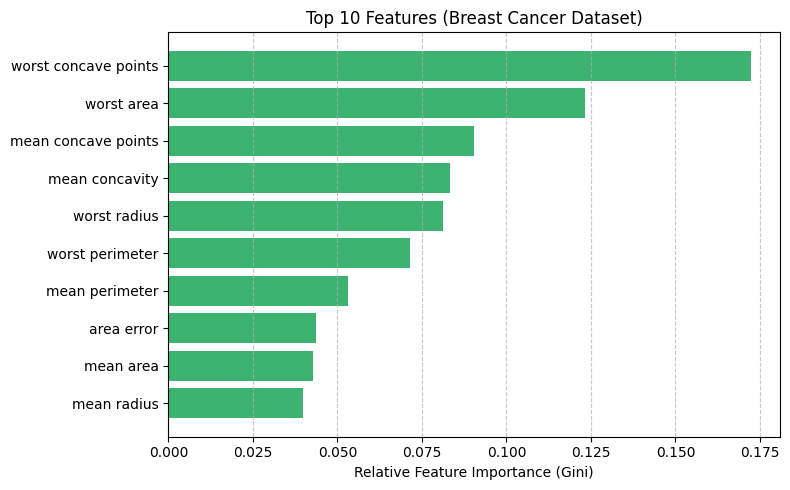

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Extract top 10 important features
importances = clf.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], color='mediumseagreen', align='center')
plt.yticks(range(len(indices)), [data.feature_names[i] for i in indices])
plt.xlabel('Relative Feature Importance (Gini)')
plt.title('Top 10 Features (Breast Cancer Dataset)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Exercises
1. Name one advantage of Feature Selection over PCA.

In [2]:
print('Feature selection preserves the original meaning and units of the features (interpretability). PCA creates new features that are mathematical linear combinations, making them difficult to interpret in business or medical contexts.')


Feature selection preserves the original meaning and units of the features (interpretability). PCA creates new features that are mathematical linear combinations, making them difficult to interpret in business or medical contexts.
